<a href="https://colab.research.google.com/github/kondapallijayasri739-glitch/student-peformance-prediction/blob/main/Movies_review_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                            Review Sentiment
0             The movie is amazing  positive
1               I loved the acting  positive
2  Excellent story and great music  positive
3                   Fantastic film  positive
4           I enjoyed every minute  positive
5                 Worst movie ever  negative
6                I hate this movie  negative
7                    Waste of time  negative
8                Very boring movie  negative
CSV file created successfully


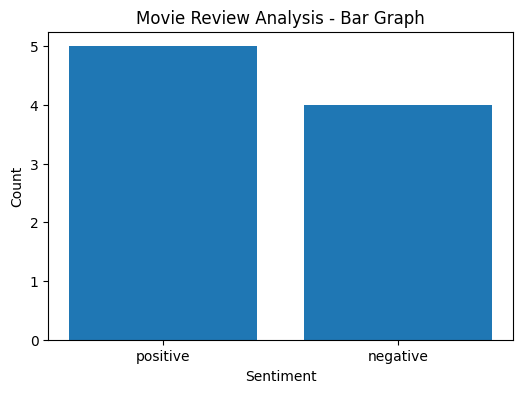

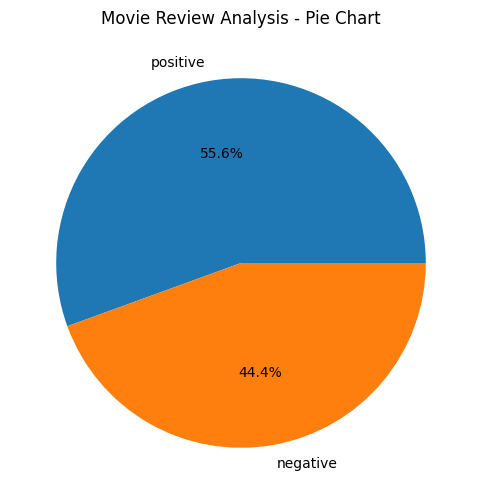

Prediction: Positive Review


In [ ]:
# Movie Review Sentiment Analysis (No file upload needed)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score


# Create dataset

reviews = [
    "The movie is amazing",
    "I loved the acting",
    "Excellent story and great music",
    "Fantastic film",
    "I enjoyed every minute",
    "Worst movie ever",
    "I hate this movie",
    "Waste of time",
    "Very boring movie"
]

sentiments = [
    "positive",
    "positive",
    "positive",
    "positive",
    "positive",
    "negative",
    "negative",
    "negative",
    "negative"
]


df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": sentiments
})


print(df)


# Save CSV
df.to_csv("Movie_Reviews.csv", index=False)

print("CSV file created successfully")


# -------------------------
# Visualization
# -------------------------

count = df["Sentiment"].value_counts()


# Bar graph
plt.figure(figsize=(6,4))
plt.bar(count.index, count.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Movie Review Analysis - Bar Graph")
plt.show()


# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    count.values,
    labels=count.index,
    autopct="%1.1f%%"
)
plt.title("Movie Review Analysis - Pie Chart")
plt.show()



# -------------------------
# Machine Learning
# -------------------------

# Convert positive/negative into numbers
df["Sentiment"] = df["Sentiment"].map({
    "positive":1,
    "negative":0
})


X = df["Review"]
y = df["Sentiment"]


# Convert text to numbers
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)


# Train model
model = MultinomialNB()

model.fit(X,y)


# Test new review

test_review = [
    "Amazing movie with excellent acting"
]


test_data = vectorizer.transform(test_review)


result = model.predict(test_data)


if result[0] == 1:
    print("Prediction: Positive Review")
else:
    print("Prediction: Negative Review")